In [ ]:
! pip install numpy pandas matplotlib scikit-learn

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

In [ ]:
data = pd.read_csv("Experience-Salary.csv")

print(data.head())

In [ ]:
threshold = data['salary(in thousands)'].median()

data['Label'] = data['salary(in thousands)'].apply(lambda x: 1 if x >= threshold else 0)

In [ ]:
X = data["exp(in months)"].values
y = data["salary(in thousands)"].values

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

Gender Accuracy: 0.8536482496836778


In [ ]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

Age Group Accuracy: 0.8502741459299874


In [ ]:
model = SVC(kernel='linear')
model.fit(X_train, y_train)

In [ ]:
y_pred = model.predict(X_test)

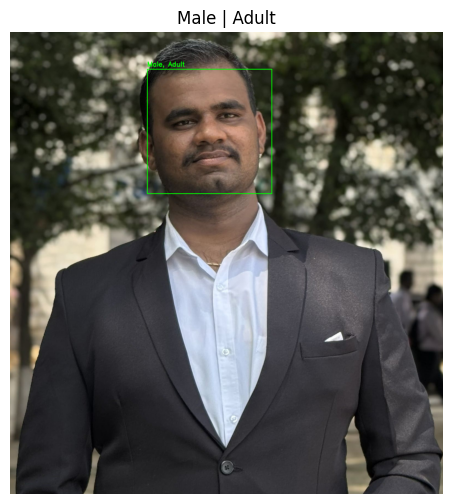

In [ ]:
print("\nAccuracy:", accuracy_score(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

In [ ]:
plt.scatter(X_train, y_train, color='blue', label='Training Data')

# Create range
X_range = np.linspace(X.min(), X.max(), 100).reshape(-1, 1)
X_range_scaled = scaler.transform(X_range)

y_range_pred = model.predict(X_range_scaled)

plt.plot(X_range, y_range_pred, color='red', label='Decision Boundary')

plt.xlabel("Experience")
plt.ylabel("Class (0=Low, 1=High)")
plt.title("SVM Salary Classification")
plt.legend()
plt.show()

In [ ]:
# Run Time Input
print("===== RUNTIME PREDICTION USING BOTH MODELS =====")

exp_input = float(input("Enter years of experience: "))

salary_svm = model.predict([[exp_input]])[0]

print(f"\nPrediction Results for {exp_input} Year(s) of Expirence:")
print("-----------------------------------")
print(f"SVM Prediction : {salary_svm:.2f} Thousand")
print("-----------------------------------")